# 4. Regression Models

Based on the datasets analysis, the regression models are proposed to forecast the time series effectively. This chapter is dedicated for the model descriptions, feature selection, tuning, training, and evaluation.

In [ ]:
import numpy as np
import pandas as pd
import ta
import datetime
import matplotlib.vpyplot as plt
from matplotlib.dates import YearLocator, MonthLocator, DayLocator, HourLocator, DateFormatter
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from statsmodels.tsa.arima.model import ARIMA, ARIMAResults
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.base import BaseEstimator

In [ ]:
dataset_gold = pd.read_csv("data/gold.csv", parse_dates=[0], index_col=0)
# Optimize data types
currencies = ['USD', 'EUR', 'JPY', 'CNY', 'RUB']
dataset_gold[currencies] = dataset_gold[currencies].apply(lambda series : series.str.replace(',', '.').str.replace('\xa0', '').astype('float64'))
dataset_gold.info()

In [ ]:
dataset_us_aug = pd.read_csv("data/gold_futures_with_indicators.csv", parse_dates=[0], index_col=0)

## I. Classical ML for Time Series

### Baseline Model
To get started with time series, create a baseline model for predicting the prices for a currency. The results would suggest the needs for optimizations if the model overfits or underfits, such as regularization, filtration, and increasing complexity. The simplest yet efficient approach is _autoregression_ (AR).

### Time Series Regression Representation
Due to the sequential manner of such series, the regression task is to extrapolate the functional dependency between time and target. For simplicity of primal analysis, assume the target is fully dependent on the previous observations only. To create features of the new dataset, decompose dataset into a set of vectors, each containing $h$ successive observations. Then, train the model on the dataset, and evaluate on unseen data by composing features in the same manner.

### AR Model for USD Gold Dataset
Initial probe of model training framework

In [3]:
def decompose_data(data: np.array, h: int) -> Tuple[np.array, np.array]:
    """
    Compose features from successive dataset objects using sliding window.

    For example, [y_1, y_2, y_3, y_4, ...] (h=2) would produce

        ([ [y_1, y_2], [y_2, y_3], ...], [y_3, y_4, ...]).

    Parameters:
        data (np.array): 1D-array of target observations.
        h (int): sliding window size.

    Returns:
        Tuple[np.array, np.array]: tuple of sampled dataset of h features
        and the target value for them.
    """
    X = sliding_window_view(data, window_shape=h)[:-1, :]
    X = np.concatenate((X, np.ones(shape=(len(X), 1))), axis=1)
    y = data[h:]
    return (X, y)

In [94]:
train_set, test_set = dataset_gold[dataset_gold.index < '2022-01-01'], dataset_gold[dataset_gold.index >= '2022-01-01']

In [95]:
# Cross-validation with training set getting larger and validation set moving further in time

K = 10
Q_mse = 0
Q_mae = 0
Q_mape = 0
Q_R2 = 0
for k in range(K):
    year = 2010 + k
    train_portion, validation_portion = train_set[train_set.index < f'{year}-01-01'], train_set[train_set.index >= f'{year}-01-01']
    
    X_train, y_train = decompose_data(train_portion['USD'], h=9)
    
    linear_regressor = LinearRegression()
    linear_regressor.fit(X_train, y_train)

    X_test, y_test = decompose_data(validation_portion['USD'], h=9)

    y_pred = linear_regressor.predict(X_test)
    Q_mse += mean_squared_error(y_test, y_pred)
    Q_mae += mean_absolute_error(y_test, y_pred)
    Q_mape += mean_absolute_percentage_error(y_test, y_pred)
    Q_R2 += r2_score(y_test, y_pred)
Q_mse /= K
Q_mae /= K
Q_mape /= K
Q_R2 /= K

In [96]:
print(f"MSE: {Q_mse}, MAE: {Q_mae}, MAPE: {Q_mape}, R2: {Q_R2}")

MSE: 2523.4539849356756, MAE: 39.36828602446719, MAPE: 0.02667036906417834, R2: 0.946775609948053


In [97]:
X_train, y_train = decompose_data(train_set['USD'], h=9)

linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)

X_test, y_test = decompose_data(test_set['USD'], h=9)

y_pred = linear_regressor.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred)}, MAE: {mean_absolute_error(y_test, y_pred)}, MAPE: {mean_absolute_percentage_error(y_test, y_pred)}, R2: {r2_score(y_test, y_pred)}")

MSE: 5679.941740923858, MAE: 58.961277764127956, MAPE: 0.025731089122926334, R2: 0.969342037888283


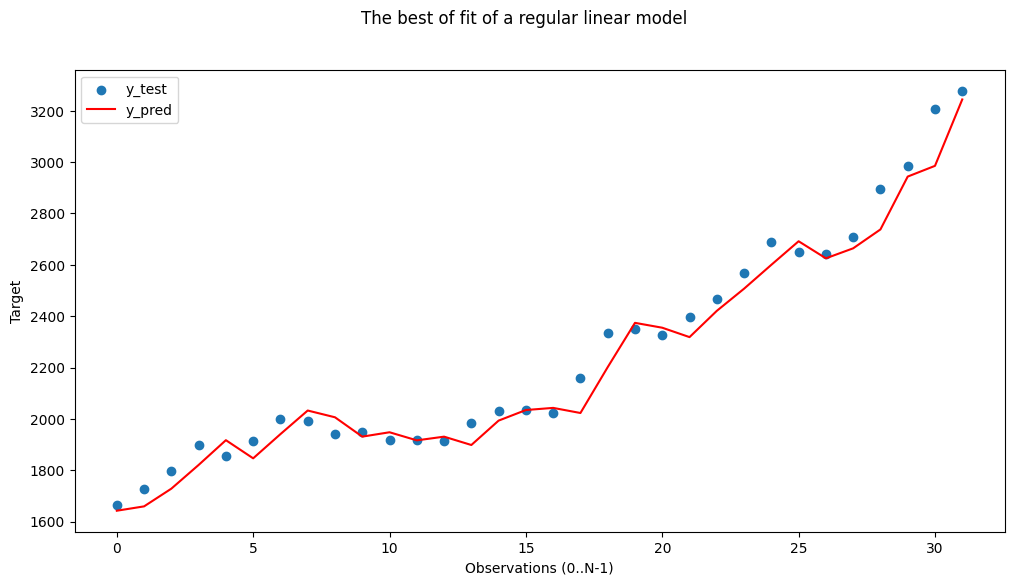

In [66]:
fig, ax = plt.subplots(nrows=1, figsize=(12, 6))
fig.suptitle("The best of fit of a regular linear model")

ax.scatter(np.arange(0, len(y_test)), y_test, label='y_test')
ax.plot(np.arange(0, len(y_test)), y_pred, color='red', label='y_pred')
ax.set_xlabel("Observations (0..N-1)")
ax.set_ylabel('Target')
ax.legend()

### ARMA and ARIMA Models for USD Gold Dataset

In [185]:
returns_usd_gld_reindexed = returns_usd_gld.asfreq('m')
dataset_usd_gld_reindexed = dataset_usd_gld.asfreq('m')

#### ARMA Model for the Original Time Series

In [195]:
train_size = int(len(dataset_usd_gld_reindexed) * 0.6)
train_set, test_set = dataset_usd_gld_reindexed.iloc[:train_size], dataset_usd_gld_reindexed.iloc[train_size:]

In [197]:
model_arima = ARIMA(train_set, order=(2, 1, 2))

In [198]:
result_arima = model_arima.fit()
result_arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    USD   No. Observations:                  239
Model:                 ARIMA(2, 1, 2)   Log Likelihood                 268.980
Date:                Thu, 19 Jun 2025   AIC                           -527.961
Time:                        21:22:37   BIC                           -510.599
Sample:                    02-29-1992   HQIC                          -520.964
                         - 12-31-2011                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0169      0.029      0.576      0.564      -0.041       0.074
ar.L2          0.9819      0.029     33.614      0.000       0.925       1.039
ma.L1         -0.0328      0.064     -0.511      0.610      -0.159       0.093
ma.L2         -0.9023      0.061    -14.734      0.000      -1.022      -0.782
sigma2         0.0017      0.000     15.565      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   3.86   Jarque-Bera (JB):              1254.10
Prob(Q):                              0.05   Prob(JB):                         0.00
Heteroskedasticity (H):              33.02   Skew:                             0.10
Prob(H) (two-sided):                  0.00   Kurtosis:                        14.24
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<Axes: title={'center': 'Residuals'}, xlabel='Date'>

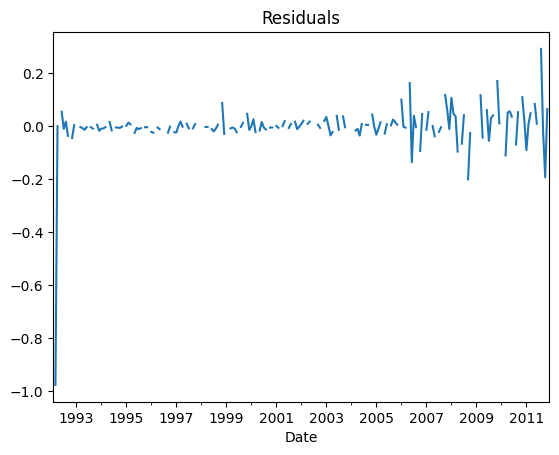

In [199]:
residuals = result_arima.resid
residuals.plot(title="Residuals")

In [200]:
y_pred = result_arima.predict(start=test_set.index[0], end=test_set.index[-1], dynamic=False)

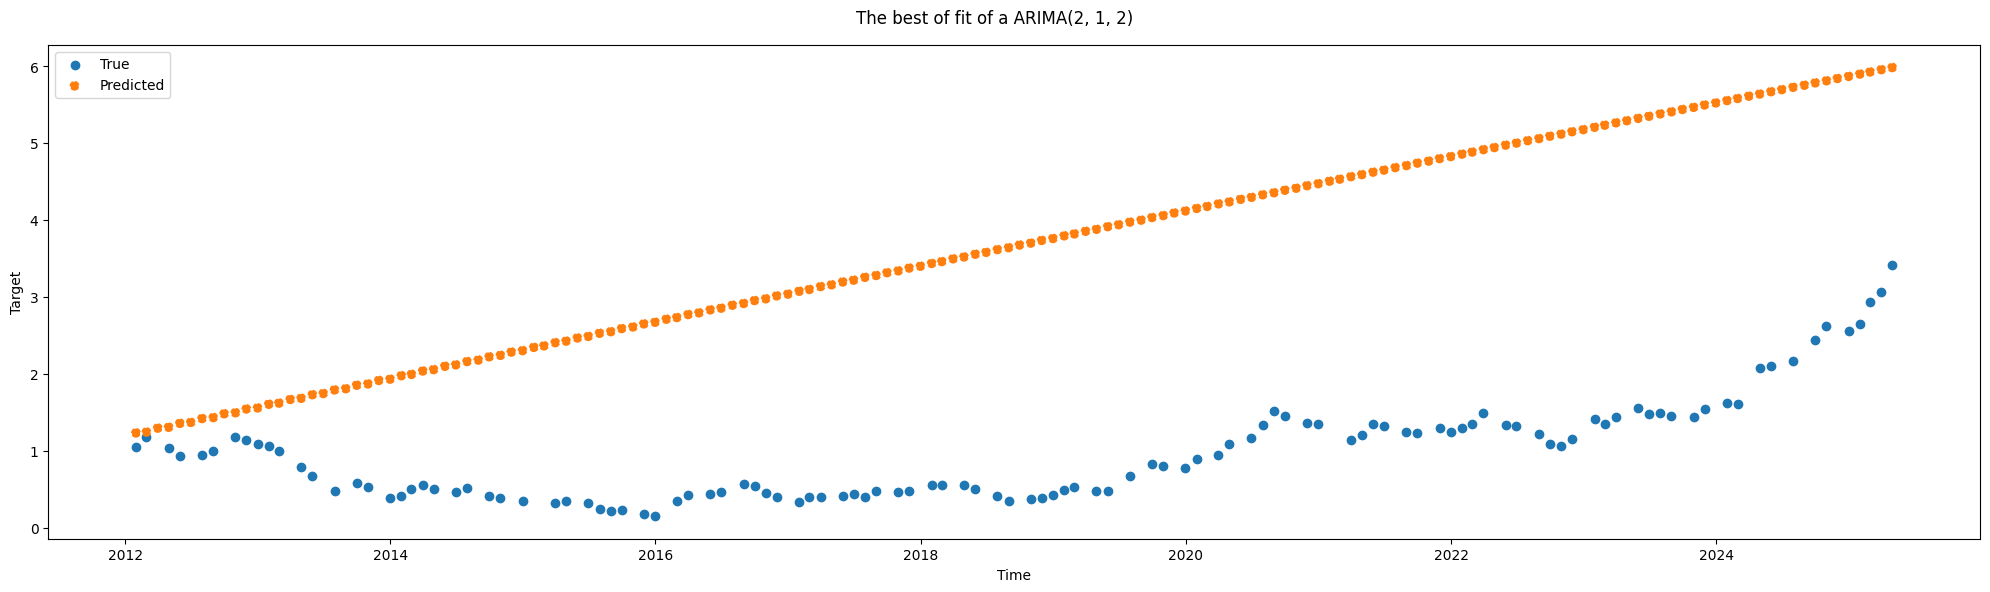

In [201]:
fig, ax = plt.subplots(nrows=1, figsize=(20, 6))
fig.suptitle("The best of fit of a ARIMA(2, 1, 2)")

ax.scatter(test_set.index, test_set, label='True')
ax.scatter(test_set.index, y_pred, label='Predicted', linestyle='--')
ax.set_xlabel("Time")
ax.set_ylabel('Target')
ax.legend()
fig.tight_layout()

#### ARMA Model for the 1st Difference Time Series

In [186]:
train_size = int(len(returns_usd_gld_reindexed) * 0.6)
train_set, test_set = returns_usd_gld_reindexed.iloc[:train_size], returns_usd_gld_reindexed.iloc[train_size:]

In [187]:
model_arma = ARIMA(train_set, order=(2, 0, 2))

In [188]:
result_arma = model_arma.fit()
result_arma.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    USD   No. Observations:                  238
Model:                 ARIMA(2, 0, 2)   Log Likelihood                -237.254
Date:                Thu, 19 Jun 2025   AIC                            486.508
Time:                        21:18:57   BIC                            507.341
Sample:                    03-31-1992   HQIC                           494.904
                         - 12-31-2011                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1812      0.243      0.744      0.457      -0.296       0.658
ar.L1          0.1000      0.407      0.246      0.806      -0.698       0.898
ar.L2          0.8738      0.398      2.196      0.028       0.094       1.654
ma.L1         -0.0396      0.378     -0.105      0.917      -0.780       0.701
ma.L2         -0.8585      0.347     -2.475      0.013      -1.538      -0.179
sigma2         0.9314      0.105      8.862      0.000       0.725       1.137
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                20.33
Prob(Q):                              0.83   Prob(JB):                         0.00
Heteroskedasticity (H):               0.96   Skew:                             0.30
Prob(H) (two-sided):                  0.86   Kurtosis:                         4.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<Axes: title={'center': 'Residuals'}, xlabel='Date'>

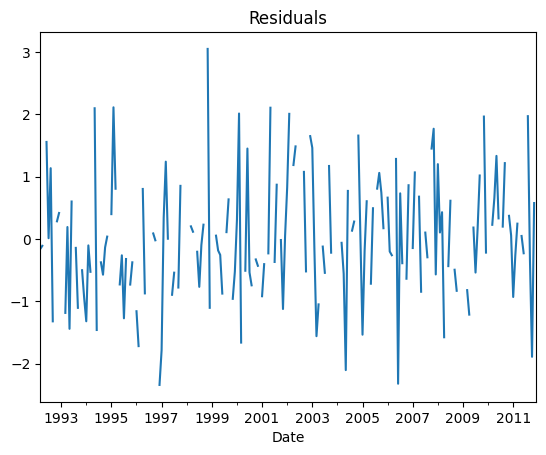

In [189]:
residuals = result_arma.resid
residuals.plot(title="Residuals")

In [190]:
y_pred = result_arma.predict(start=test_set.index[0], end=test_set.index[-1], dynamic=False)

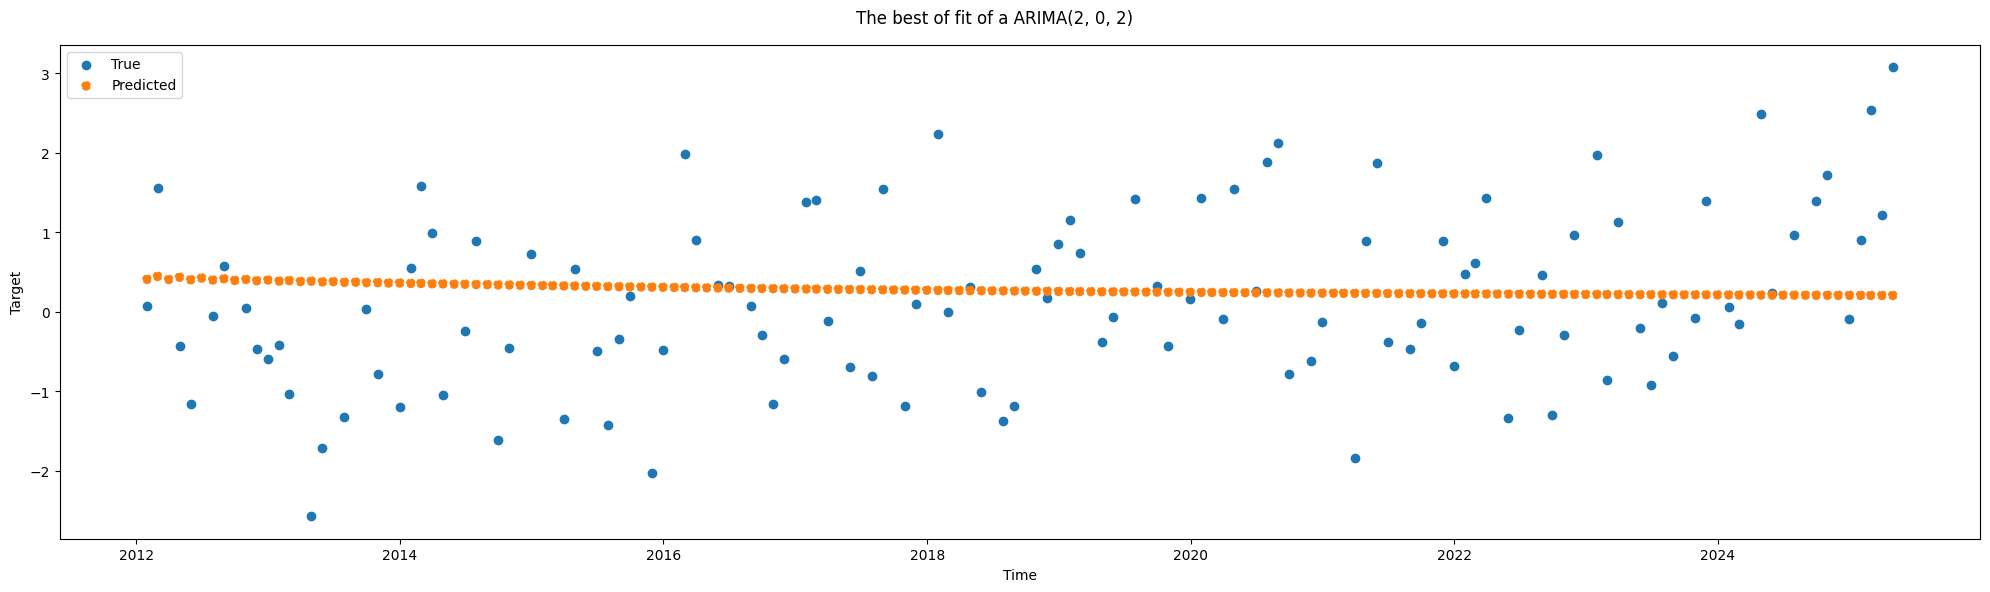

In [194]:
fig, ax = plt.subplots(nrows=1, figsize=(20, 6))
fig.suptitle("The best of fit of a ARIMA(2, 0, 2)")

ax.scatter(test_set.index, test_set, label='True')
ax.scatter(test_set.index, y_pred, label='Predicted', linestyle='--')
ax.set_xlabel("Time")
ax.set_ylabel('Target')
ax.legend()
fig.tight_layout()

### ARIMA Models for American Futures Gold Dataset
The rest of the analysis is dedicated to the American Futures Gold dataset due to availability of additional features.

#### ARMA model for difference time series

In [152]:
returns_us_aug_reindexed = returns_us_aug.asfreq('h')
dataset_aug_cls_reindexed = dataset_aug_cls.asfreq('h')

train_size = int(len(dataset_aug_cls_reindexed) * 0.98)
train_set, test_set = dataset_aug_cls_reindexed.iloc[:train_size], dataset_aug_cls_reindexed.iloc[train_size:]
# train_set, test_set = dataset_aug_cls_reindexed[dataset_aug_cls_reindexed.index < '2024-06-01'], dataset_aug_cls_reindexed[dataset_aug_cls_reindexed.index >= '2024-06-02']

In [153]:
model_arma = ARIMA(train_set, order=(2, 0, 2))

In [154]:
result_arma = model_arma.fit()
result_arma.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                17149
Model:                 ARIMA(2, 0, 2)   Log Likelihood               33366.061
Date:                Thu, 19 Jun 2025   AIC                         -66720.122
Time:                        21:06:22   BIC                         -66673.624
Sample:                    06-11-2023   HQIC                        -66704.795
                         - 05-26-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0495      5.567     -0.009      0.993     -10.961      10.862
ar.L1          0.0074      0.011      0.683      0.495      -0.014       0.029
ar.L2          0.9926      0.011     91.578      0.000       0.971       1.014
ma.L1          0.9367      0.012     78.165      0.000       0.913       0.960
ma.L2         -0.0539      0.005    -10.357      0.000      -0.064      -0.044
sigma2         0.0001   6.72e-07    212.258      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   4.86   Jarque-Bera (JB):            391612.97
Prob(Q):                              0.03   Prob(JB):                         0.00
Heteroskedasticity (H):               4.80   Skew:                            -0.16
Prob(H) (two-sided):                  0.00   Kurtosis:                        26.41
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
residuals = result_arma.resid
residuals.plot(title="Residuals")

In [156]:
y_pred = result_arma.predict(start=test_set.index[0], end=test_set.index[-1], dynamic=False)

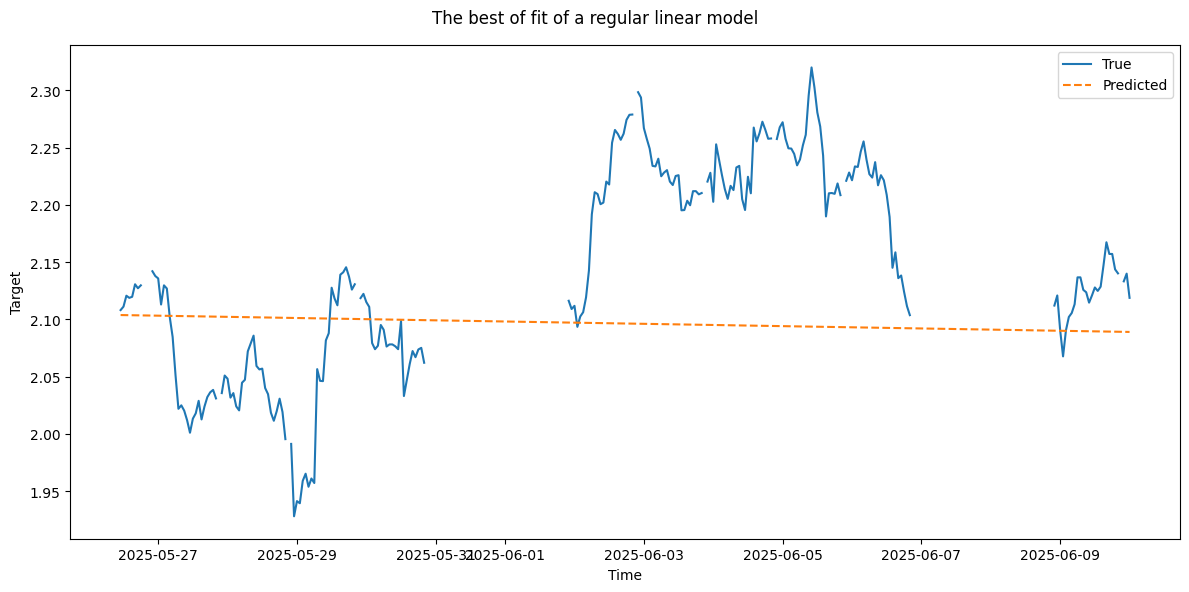

In [160]:
fig, ax = plt.subplots(nrows=1, figsize=(12, 6))
fig.suptitle("The best of fit of ARIMA(2, 0, 2)")

ax.plot(test_set.index, test_set, label='True')
ax.plot(test_set.index, y_pred, label='Predicted', linestyle='--')
ax.set_xlabel("Time")
ax.set_ylabel('Target')
ax.legend()
fig.tight_layout()

### Rolling Forecast Origin ARIMA Model

In [ ]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

In [ ]:
window_size = 24*10  # in hours
forecast_horizon = 250
y_pred = []
y_test = []

# Iterate through test set with rolling window
for start in range(0, len(test_set) - forecast_horizon + 1):
    if (start+1) % 10 == 0:
        print(f"Progress of iteratations: {start+1}/{len(test_set) - forecast_horizon}")
    window_end = train_size + start
    window_start = window_end - window_size

    if window_start < 0:
        continue  # skip if there's not enough history for the window

    train_window = dataset_aug_cls_reindexed.iloc[window_start:window_end]
    
    # Fit ARIMA(2,0,2)
    try:
        model = ARIMA(train_window, order=(2, 0, 2))
        model_fit = model.fit()
        forecast = model_fit.forecast(steps=forecast_horizon)
        y_pred.append(forecast.iloc[0])
        y_test.append(dataset_aug_cls_reindexed.iloc[window_end])
    except Exception as e:
        print(f"Model failed at index {window_end}: {e}")
        continue

In [140]:
# Handle NaNs (from reindexing by hour frequency) by imputing with mean

y_test = np.array(y_test)
mean_value = np.nanmean(y_test)
y_test[np.where(np.isnan(y_test))] = mean_value

y_pred = np.array(y_pred)

MSE: 0.000581042577359204,MAE: 0.015220680561845204,MAPE: 0.0074110832765095815, R2: 0.7852972781311208


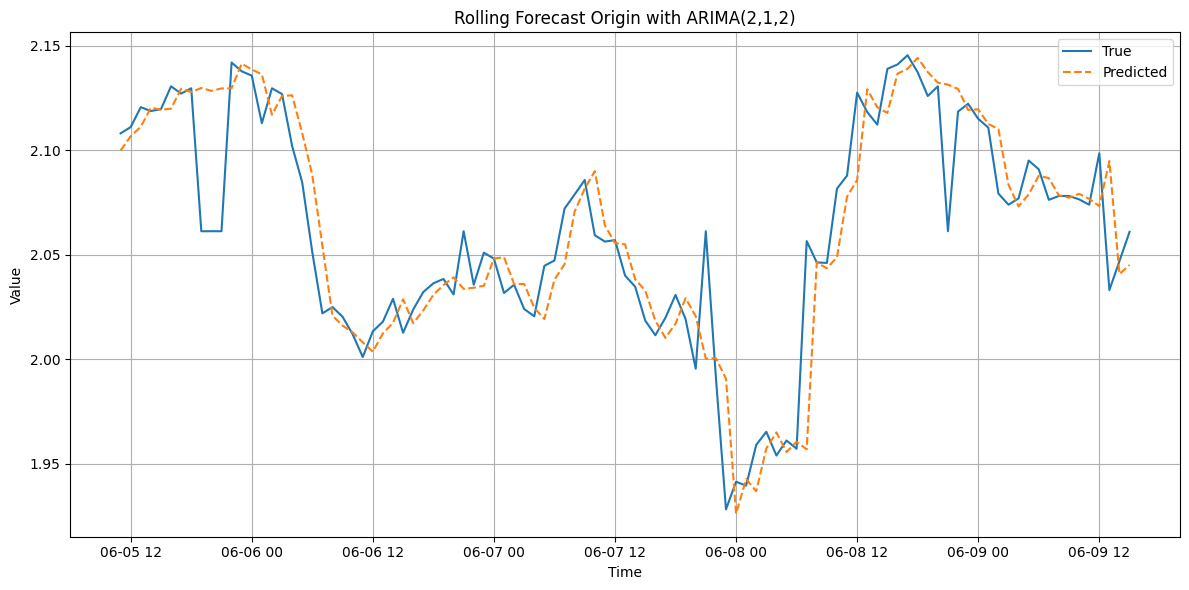

In [143]:
print(
    (f"MSE: {mean_squared_error(y_test, y_pred)},"
    f"MAE: {mean_absolute_error(y_test, y_pred)},"
    f"MAPE: {mean_absolute_percentage_error(y_test, y_pred)}, R2: {r2_score(y_test, y_pred)}")
)

# Plot predictions vs actual
plt.figure(figsize=(12, 6))
plt.plot(dataset_aug_cls_reindexed.iloc[train_size + window_size:train_size + window_size + len(y_pred)].index, y_pred, label='True')
plt.plot(dataset_aug_cls_reindexed.iloc[train_size + window_size:train_size + window_size + len(y_pred)].index, y_test, label='Predicted', linestyle='--')
plt.title('Rolling Forecast Origin with ARIMA(2,1,2)')
plt.xlabel('Time')
plt.ylabel('Target')
plt.legend()
plt.grid(True)
plt.show()

### AR model with augmented features

In [312]:
def decompose_tabular_data(data: np.array, h: int) -> Tuple[np.array, np.array]:
    """
    Compose features from successive dataset objects using sliding window.

    For example, [y_1, y_2, y_3, y_4, ...] (h=2) would produce

        ([ [*y_1, *y_2, y_3[:, 1:]], [*y_2, *y_3, y_4[:, 1:]], ...], [y_3, y_4, ...]).

    Here *a means unpacking values from a vector.

    Parameters:
        data (np.array): 2D-array of target observations.
        h (int): sliding window size.

    Returns:
        Tuple[np.array, np.array]: tuple of sampled dataset of h features
        and the target value for them.
    """
    X = sliding_window_view(data, window_shape=(h, data.shape[1])).reshape(-1, h * data.shape[1])[:-1, :]
    y = data[h:]
    target, features = y[:, 0], y[:, 1:]
    X = np.hstack([X, features, np.ones(shape=(X.shape[0], 1))])
    return (X, target)

In [99]:
# Cross Validation Split
K = 20
tss = TimeSeriesSplit(n_splits=K, test_size=24*10*1, gap=24)

In [29]:
dataset = dataset_us_aug.copy()

# First difference to remove trend (as proposed in Section 2)
dataset['Close'] = dataset['Close'].diff()
dataset = dataset.dropna()

In [30]:
X, y = decompose_tabular_data(dataset.to_numpy(), 3)
X.shape, y.shape

((10485, 34), (10485,))

In [102]:
Xy = pd.DataFrame(X, y)

In [107]:
preds = []
Q_mse = 0
Q_mae = 0
Q_mape = 0
Q_R2 = 0

for train_idx, val_idx in tss.split(Xy):
    train = Xy.iloc[train_idx]
    val = Xy.iloc[val_idx]

    X_train, y_train = train.to_numpy(), train.index.to_numpy()
    X_val, y_val = val.to_numpy(), val.index.to_numpy()

    regressor = LinearRegression()

    regressor.fit(X_train, y_train)

    y_pred = regressor.predict(X_val)
    preds.append(y_pred)
    Q_mse += mean_squared_error(y_val, y_pred)
    Q_mae += mean_absolute_error(y_val, y_pred)
    Q_mape += mean_absolute_percentage_error(y_val, y_pred)
    Q_R2 += r2_score(y_val, y_pred)

Q_mse /= K
Q_mae /= K
Q_mape /= K
Q_R2 /= K

In [110]:
print(f"MSE: {Q_mse}, MAE: {Q_mae}, MAPE: {Q_mape}, R2: {Q_R2}")

MSE: 3.6245090259221944e-23, MAE: 4.532296144291182e-12, MAPE: 192.95490885417047, R2: 1.0


In [109]:
dataset_train, dataset_test = dataset[dataset.index < '2025-05-01'], dataset[dataset.index >= '2025-05-01']

X_train, y_train = decompose_tabular_data(dataset_train.to_numpy(), h=3)
X_test, y_test = decompose_tabular_data(dataset_test.to_numpy(), h=3)

regressor = LinearRegression()

regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred)}, MAE: {mean_absolute_error(y_test, y_pred)}, MAPE: {mean_absolute_percentage_error(y_test, y_pred)}, R2: {r2_score(y_test, y_pred)}")

MSE: 3.47291635870431e-23, MAE: 4.408442366571558e-12, MAPE: 389.6875975039026, R2: 1.0


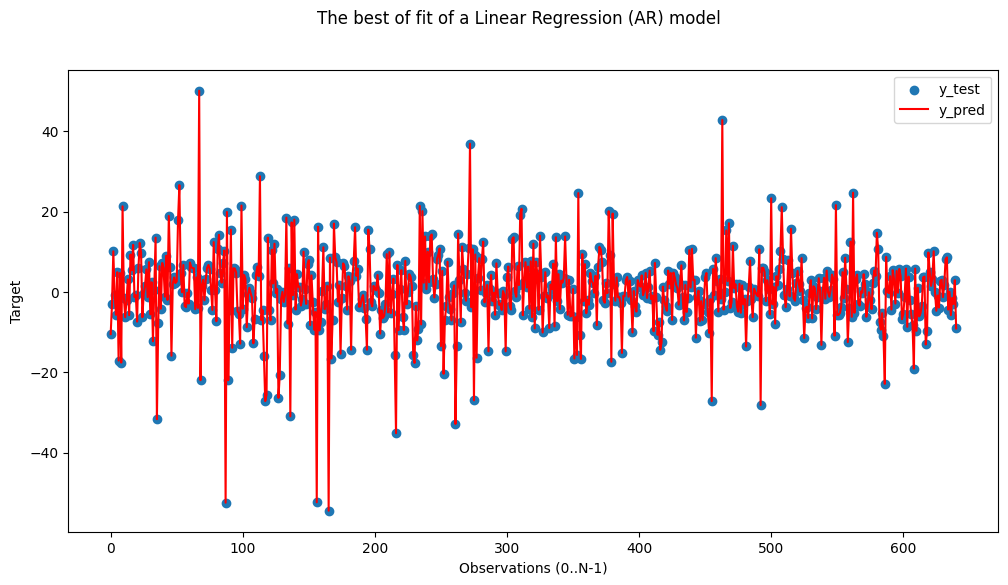

In [112]:
fig, ax = plt.subplots(nrows=1, figsize=(12, 6))
fig.suptitle("The best fit of a Linear Regression (AR) model")

ax.scatter(np.arange(0, len(y_test)), y_test, label='y_test')
ax.plot(np.arange(0, len(y_test)), y_pred, color='red', label='y_pred')
ax.set_xlabel("Observations (0..N-1)")
ax.set_ylabel('Target')
ax.legend()

### XGBoost Model

In [79]:
# Cross Validation Split
K = 20
tss = TimeSeriesSplit(n_splits=K, test_size=24*10*1, gap=24)

In [80]:
dataset = dataset_us_aug.copy()

# First difference to remove trend (as proposed in Section 2)
dataset['Close'] = dataset['Close'].diff()
dataset = dataset.dropna()

In [81]:
X, y = decompose_tabular_data(dataset.to_numpy(), 3)
X.shape, y.shape

((11431, 44), (11431,))

In [82]:
Xy = pd.DataFrame(X, y)

In [103]:
preds = []
Q_mse = 0
Q_mae = 0
Q_mape = 0
Q_R2 = 0

for train_idx, val_idx in tss.split(Xy):
    train = Xy.iloc[train_idx]
    val = Xy.iloc[val_idx]

    X_train, y_train = train.to_numpy(), train.index.to_numpy()
    X_val, y_val = val.to_numpy(), val.index.to_numpy()

    regressor = XGBRegressor(
        base_score=.5,
        booster='gbtree',
        early_stopping_rounds=10,
        objective='reg:squarederror',
        max_depth=3,
        learning_rate=.05
    )

    regressor.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=100)

    y_pred = regressor.predict(X_val)
    preds.append(y_pred)
    Q_mse += mean_squared_error(y_val, y_pred)
    Q_mae += mean_absolute_error(y_val, y_pred)
    Q_mape += mean_absolute_percentage_error(y_val, y_pred)
    Q_R2 += r2_score(y_val, y_pred)

Q_mse /= K
Q_mae /= K
Q_mape /= K
Q_R2 /= K

[0]	validation_0-rmse:4.00044	validation_1-rmse:4.08348
[99]	validation_0-rmse:1.97815	validation_1-rmse:1.93475
[0]	validation_0-rmse:4.00388	validation_1-rmse:3.82579
[99]	validation_0-rmse:1.97856	validation_1-rmse:1.83384
[0]	validation_0-rmse:3.99291	validation_1-rmse:4.22264
[99]	validation_0-rmse:1.98688	validation_1-rmse:2.31485
[0]	validation_0-rmse:4.01006	validation_1-rmse:4.85359
[99]	validation_0-rmse:1.98420	validation_1-rmse:2.50703
[0]	validation_0-rmse:4.03156	validation_1-rmse:3.98514
[99]	validation_0-rmse:1.98070	validation_1-rmse:2.03881
[0]	validation_0-rmse:4.03451	validation_1-rmse:4.72749
[99]	validation_0-rmse:1.98625	validation_1-rmse:2.71560
[0]	validation_0-rmse:4.03886	validation_1-rmse:5.82139
[99]	validation_0-rmse:1.98303	validation_1-rmse:3.97287
[0]	validation_0-rmse:4.11823	validation_1-rmse:6.46013
[99]	validation_0-rmse:2.06300	validation_1-rmse:4.01274
[0]	validation_0-rmse:4.19613	validation_1-rmse:5.24839
[99]	validation_0-rmse:2.09706	validatio

In [104]:
print(f"MSE: {Q_mse}, MAE: {Q_mae}, MAPE: {Q_mape}, R2: {Q_R2}")

MSE: 19.87474036227396, MAE: 2.6270514701046825, MAPE: 18215222598697.703, R2: 0.6502512120770085


In [113]:
dataset_train, dataset_test = dataset[dataset.index < '2025-05-01'], dataset[dataset.index >= '2025-05-01']

X_train, y_train = decompose_tabular_data(dataset_train.to_numpy(), h=3)
X_test, y_test = decompose_tabular_data(dataset_test.to_numpy(), h=3)

regressor = XGBRegressor(
    base_score=.5,
    booster='gbtree',
    early_stopping_rounds=10,
    objective='reg:squarederror',
    max_depth=3,
    learning_rate=.05
)

regressor.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

y_pred = regressor.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred)}, MAE: {mean_absolute_error(y_test, y_pred)}, MAPE: {mean_absolute_percentage_error(y_test, y_pred)}, R2: {r2_score(y_test, y_pred)}")

MSE: 41.5174234923925, MAE: 4.208985753904435, MAPE: 30214889727090.17, R2: 0.5739424126993363


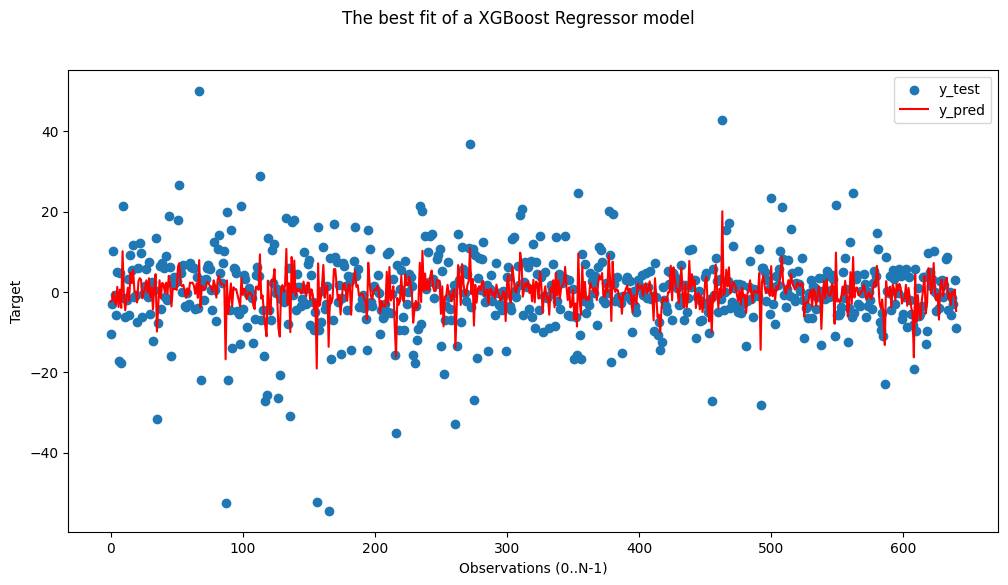

In [114]:
fig, ax = plt.subplots(nrows=1, figsize=(12, 6))
fig.suptitle("The best fit of a XGBoost Regressor model")

ax.scatter(np.arange(0, len(y_test)), y_test, label='y_test')
ax.plot(np.arange(0, len(y_test)), y_pred, color='red', label='y_pred')
ax.set_xlabel("Observations (0..N-1)")
ax.set_ylabel('Target')
ax.legend()

Recovery of original time series (price) from difference:

In [87]:
price_prediction = y_train[-1] + np.cumsum(y_pred)

Dumping baseline model information

In [88]:
# regressor.save_model("model.json")